In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mplsoccer import Pitch, VerticalPitch
from statsbombpy import sb

import pathlib
import os
import pandas as pd
import json

/Users/giorgistsoukaris/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Plotting

## 1st Project

In [2]:
#importing SBopen class from mplsoccer to open the data
from mplsoccer import Sbopen
# The first thing we have to do is open the data. We use a parser SBopen available in mplsoccer.
parser = Sbopen()

#opening data using match method where competition_id 55 is UEFA Euros and season id 282 is for 2024 competition
#this returns every match of uefa euro 2024
df_match = parser.match(competition_id=55, season_id=282)

uefa euro competition id = 55, season id = 282

In [3]:
df_match.head()

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,...,competition_stage_id,competition_stage_name,stadium_id,stadium_name,stadium_country_id,stadium_country_name,referee_id,referee_name,referee_country_id,referee_country_name
0,3942819,2024-07-10,2024-07-10 22:00:00,1,2,available,available,2024-07-15 07:54:23.583297,2024-07-15 07:57:36.684453,6,...,15,Semi-finals,373,Signal-Iduna-Park,85,Germany,241,Felix Zwayer,85,Germany
1,3943043,2024-07-14,2024-07-14 22:00:00,2,1,available,available,2024-07-15 15:48:50.315500,2024-07-15 15:52:24.778809,7,...,26,Final,367,Olympiastadion Berlin,85,Germany,79,François Letexier,78,France
2,3942752,2024-07-09,2024-07-09 22:00:00,2,1,available,available,2024-07-10 08:51:07.032303,2024-07-10 13:01:26.597509,6,...,15,Semi-finals,4867,Allianz Arena,85,Germany,943,Slavko Vinčić,208,Slovenia
3,3942382,2024-07-06,2024-07-06 22:00:00,2,1,available,available,2024-07-10 06:50:04.068615,2024-07-10 06:56:35.146850,5,...,11,Quarter-finals,367,Olympiastadion Berlin,85,Germany,76,Clément Turpin,78,France
4,3942349,2024-07-05,2024-07-05 22:00:00,0,0,available,available,2024-07-12 01:57:15.210934,2024-07-12 02:00:16.871522,5,...,11,Quarter-finals,379,Volksparkstadion,85,Germany,1,Michael Oliver,68,England


In [4]:
#A dataframe of shots only
slovenia_games_df= df_match.loc[(df_match['home_team_name'] == 'Slovenia') | (df_match['away_team_name'] == 'Slovenia')]

## lineup

In [5]:
Cerin = "Adam Gnezda Čerin"

## Events

In [6]:
#opening data
df_event_Portugal, df_related_Porugal, df_freeze_Porugal, df_tactics_Porugal = parser.event(3941020)
#structure of data
df_event_Portugal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4221 entries, 0 to 4220
Data columns (total 78 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              4221 non-null   object 
 1   index                           4221 non-null   int64  
 2   period                          4221 non-null   int64  
 3   timestamp                       4221 non-null   object 
 4   minute                          4221 non-null   int64  
 5   second                          4221 non-null   int64  
 6   possession                      4221 non-null   int64  
 7   duration                        3156 non-null   float64
 8   match_id                        4221 non-null   int64  
 9   type_id                         4221 non-null   int64  
 10  type_name                       4221 non-null   object 
 11  possession_team_id              4221 non-null   int64  
 12  possession_team_name            42

In [7]:
#get team names
team1, team2 = df_event_Portugal.team_name.unique()

In [8]:
#A dataframe of shots
shots = df_event_Portugal.loc[df_event_Portugal['type_name'] == 'Shot'].set_index('id')

In [9]:
#A dataframe of shots only
slovenia_games_df= df_match.loc[(df_match['home_team_name'] == 'Slovenia') | (df_match['away_team_name'] == 'Slovenia')]
mask_slovenia = (df_event_Portugal.type_name == 'Shot') & (df_event_Portugal.team_name == team1)
df_slovenia = df_event_Portugal.loc[mask_slovenia, ['x', 'y', 'outcome_name', "player_name", "shot_statsbomb_xg"]]

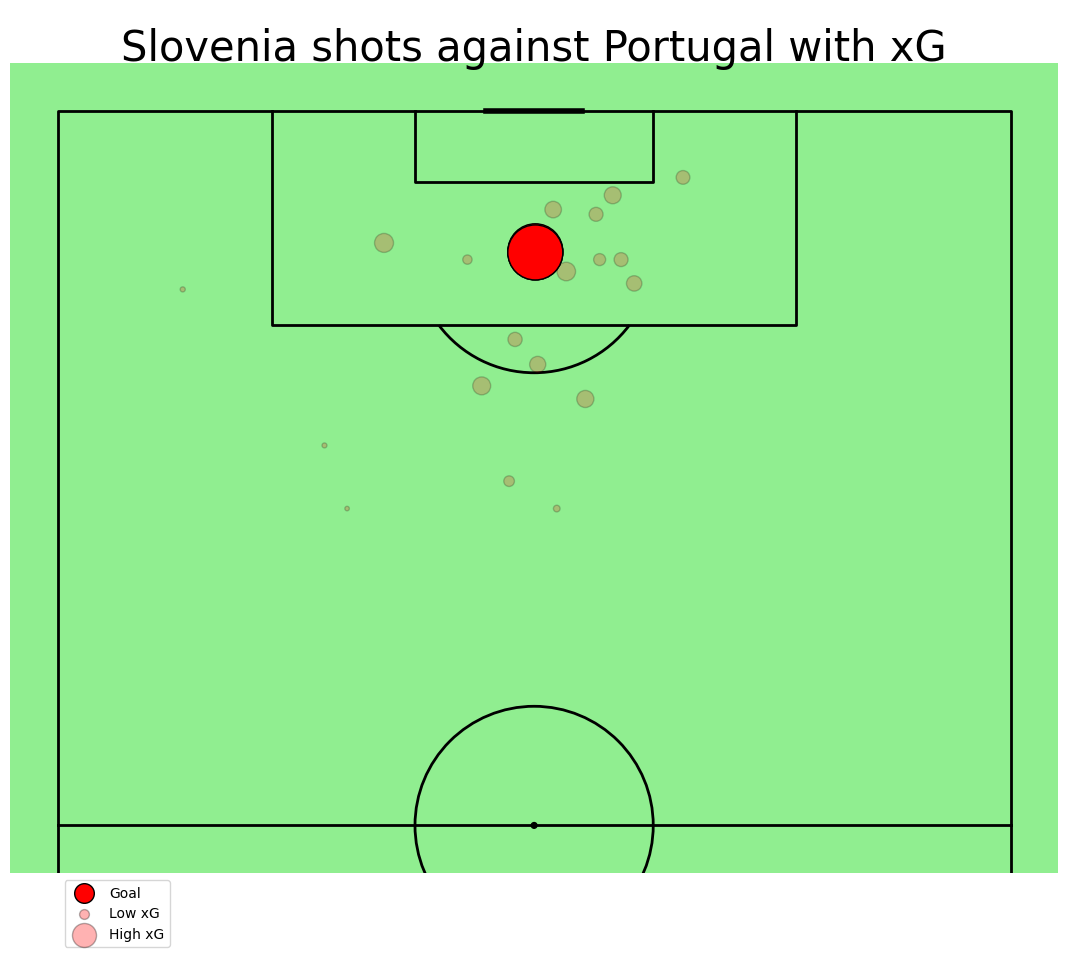

In [10]:
# Create a green pitch
pitch = VerticalPitch(line_color='black', pitch_color='#90EE90', half=True)

# Set alpha based on whether the shot is a goal or not
alpha_values = df_slovenia['outcome_name'].apply(lambda x: 1 if x == 'Goal' else 0.2)


# Plotting all shots with respective alpha values
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)

pitch.scatter(df_slovenia.x, df_slovenia.y, alpha=alpha_values, 
              s=df_slovenia.shot_statsbomb_xg * 2000, color="red", 
              ax=ax['pitch'], edgecolors="black")

# Adding the title

fig.suptitle("Slovenia shots against Portugal with xG", fontsize=30)
# Add the legend
import matplotlib.patches as mpatches

# Create dummy scatter points for legend
goal_scatter = plt.scatter([], [], s=200, color="red", edgecolors="black", label="Goal")

# Create a legend entry for xG size representation
xg_legend1 = plt.scatter([], [], s=50, color="red", alpha=0.3, edgecolors="black", label="Low xG")
xg_legend2 = plt.scatter([], [], s=300, color="red", alpha=0.3, edgecolors="black", label="High xG")
plt.legend(handles=[goal_scatter, xg_legend1, xg_legend2], loc=2)
plt.show()

## Uncover stories in the match against Portugal

## Passing

In [11]:
passes_portugal = df_event_Portugal.loc[df_event_Portugal['type_name'] == 'Pass'].loc[df_event_Portugal['sub_type_name'] != 'Throw-in'].set_index('id')


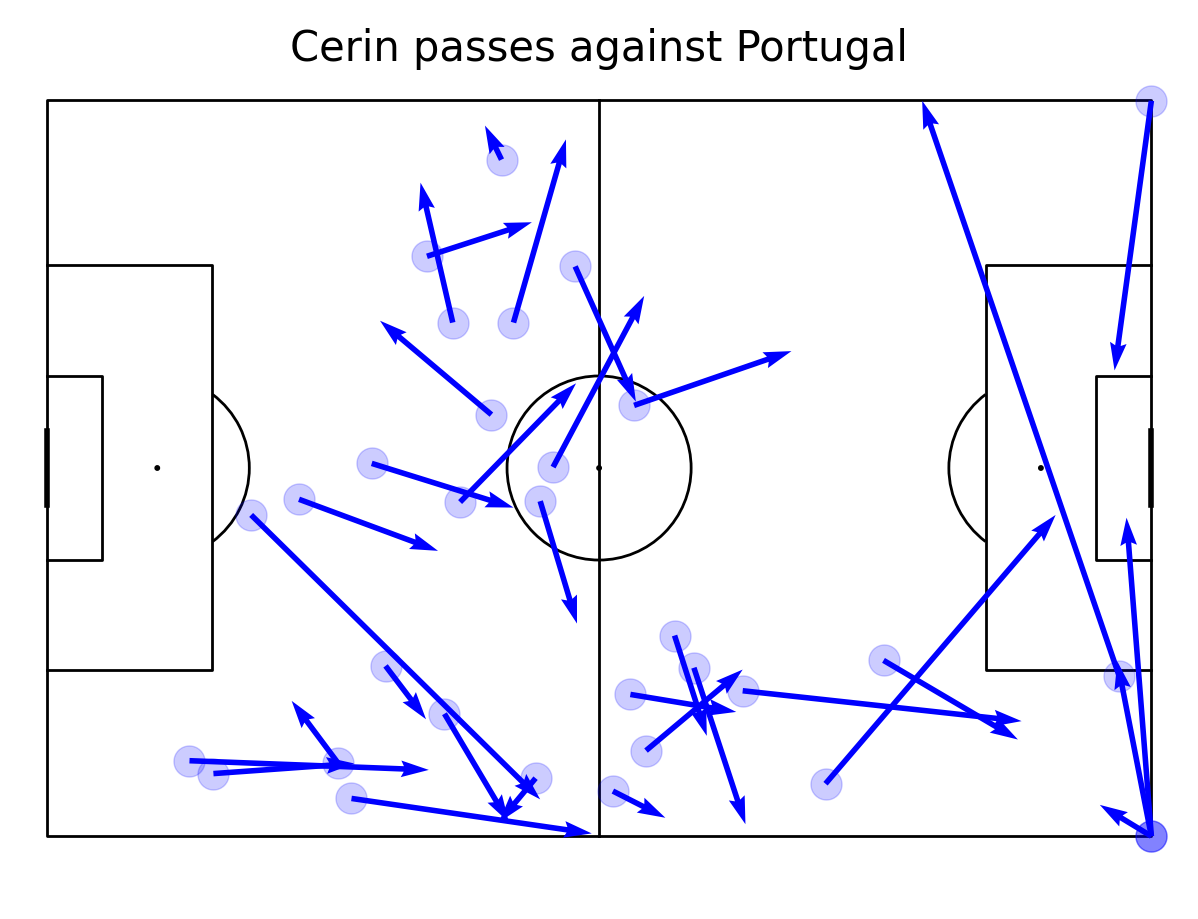

In [12]:
mask_cerin = (passes_portugal.type_name == 'Pass') & (passes_portugal.player_name == Cerin)
df_pass = passes_portugal.loc[mask_cerin, ['x', 'y', 'end_x', 'end_y']]

pitch = Pitch(line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.arrows(df_pass.x, df_pass.y,
            df_pass.end_x, df_pass.end_y, color = "blue", ax=ax['pitch'])
pitch.scatter(df_pass.x, df_pass.y, alpha = 0.2, s = 500, color = "blue", ax=ax['pitch'])
fig.suptitle("Cerin passes against Portugal", fontsize = 30)
plt.show()

## Pass Network

In [13]:
#check for index of first sub
sub = df_event_Portugal.loc[df_event_Portugal["type_name"] == "Substitution"].loc[df_event_Portugal["team_name"] == "Slovenia"].iloc[0]["index"]
#make df with successfull passes by England until the first substitution
mask_Slovenia = (df_event_Portugal.type_name == 'Pass') & (df_event_Portugal.team_name == "Slovenia") & (df_event_Portugal.index < sub) & (df_event_Portugal.outcome_name.isnull()) & (df_event_Portugal.sub_type_name != "Throw-in")
#taking necessary columns
df_pass = df_event_Portugal.loc[mask_Slovenia, ['x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]
#adjusting that only the surname of a player is presented.
df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])

In [14]:
scatter_df = pd.DataFrame()
for i, name in enumerate(df_pass["player_name"].unique()):
    passx = df_pass.loc[df_pass["player_name"] == name]["x"].to_numpy()
    recx = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_x"].to_numpy()
    passy = df_pass.loc[df_pass["player_name"] == name]["y"].to_numpy()
    recy = df_pass.loc[df_pass["pass_recipient_name"] == name]["end_y"].to_numpy()
    scatter_df.at[i, "player_name"] = name
    #make sure that x and y location for each circle representing the player is the average of passes and receptions
    scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
    scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))
    #calculate number of passes
    scatter_df.at[i, "no"] = df_pass.loc[df_pass["player_name"] == name].count().iloc[0]

#adjust the size of a circle so that the player who made more passes
scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1500)

In [15]:
#counting passes between players
df_pass["pair_key"] = df_pass.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
lines_df = df_pass.groupby(["pair_key"]).x.count().reset_index()
lines_df.rename({'x':'pass_count'}, axis='columns', inplace=True)
#setting a treshold. You can try to investigate how it changes when you change it.
lines_df = lines_df[lines_df['pass_count']>2]

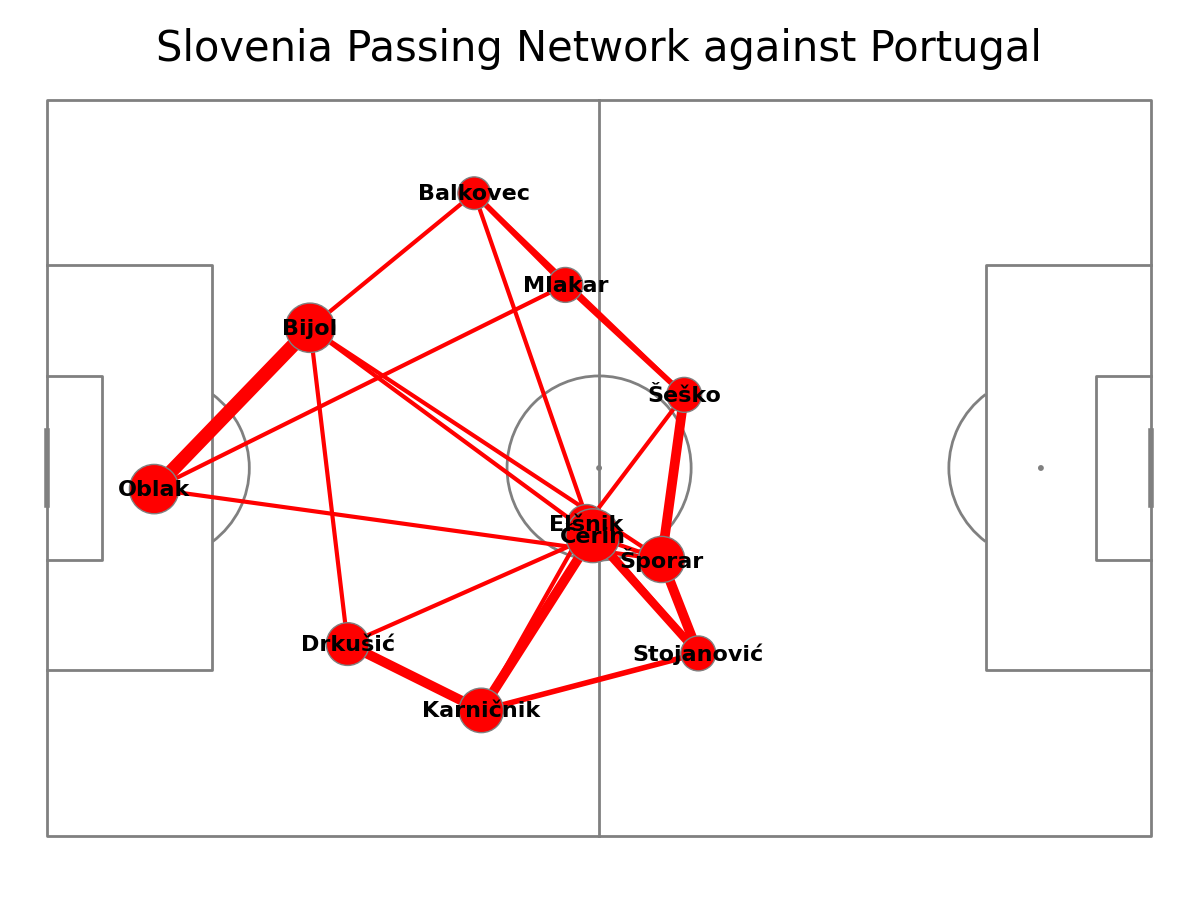

In [16]:
#plot once again pitch and vertices
pitch = Pitch(line_color='grey')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
pitch.scatter(scatter_df.x, scatter_df.y, s=scatter_df.marker_size, color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax["pitch"], zorder = 3)
for i, row in scatter_df.iterrows():
    pitch.annotate(row.player_name, xy=(row.x, row.y), c='black', va='center', ha='center', weight = "bold", size=16, ax=ax["pitch"], zorder = 4)

for i, row in lines_df.iterrows():
        player1 = row["pair_key"].split("_")[0]
        player2 = row['pair_key'].split("_")[1]
        #take the average location of players to plot a line between them
        player1_x = scatter_df.loc[scatter_df["player_name"] == player1]['x'].iloc[0]
        player1_y = scatter_df.loc[scatter_df["player_name"] == player1]['y'].iloc[0]
        player2_x = scatter_df.loc[scatter_df["player_name"] == player2]['x'].iloc[0]
        player2_y = scatter_df.loc[scatter_df["player_name"] == player2]['y'].iloc[0]
        num_passes = row["pass_count"]
        #adjust the line width so that the more passes, the wider the line
        line_width = (num_passes / lines_df['pass_count'].max() * 10)
        #plot lines on the pitch
        pitch.lines(player1_x, player1_y, player2_x, player2_y,
                        alpha=1, lw=line_width, zorder=2, color="red", ax = ax["pitch"])

fig.suptitle("Slovenia Passing Network against Portugal", fontsize = 30)
plt.show()

In [17]:
#calculate number of successful passes by player
no_passes = df_pass.groupby(['player_name']).x.count().reset_index()
no_passes.rename({'x':'pass_count'}, axis='columns', inplace=True)
#find one who made most passes
max_no = no_passes["pass_count"].max()
#calculate the denominator - 10*the total sum of passes
denominator = 10*no_passes["pass_count"].sum()
#calculate the nominator
nominator = (max_no - no_passes["pass_count"]).sum()
#calculate the centralisation index
centralisation_index = nominator/denominator
print("Centralisation index is ", centralisation_index)

Centralisation index is  0.059541984732824425


## Pass heat map

In [18]:
#our team
team = "Slovenia"
#get list of games by our team, either home or away
match_ids = slovenia_games_df.loc[(slovenia_games_df["home_team_name"] == team) | (slovenia_games_df["away_team_name"] == team)]["match_id"].tolist()
#calculate number of games
no_games = len(match_ids)

In [19]:
#declare an empty dataframe
danger_passes = pd.DataFrame()
for idx in match_ids:
    #open the event data from this game
    df = parser.event(idx)[0]
    for period in [1, 2]:
        #keep only accurate passes by England that were not set pieces in this period
        mask_pass = (df.team_name == team) & (df.type_name == "Pass") & (df.outcome_name.isnull()) & (df.period == period) & (df.sub_type_name.isnull())
        #keep only necessary columns
        passes = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]
        #keep only Shots by England in this period
        mask_shot = (df.team_name == team) & (df.type_name == "Shot") & (df.period == period) & (df.shot_statsbomb_xg > 0.06)
        #keep only necessary columns
        shots = df.loc[mask_shot, ["minute", "second"]]
        #convert time to seconds
        shot_times = shots['minute']*60+shots['second']
        shot_window = 15
        #find starts of the window
        shot_start = shot_times - shot_window
        #condition to avoid negative shot starts
        shot_start = shot_start.apply(lambda i: i if i>0 else (period-1)*45)
        #convert to seconds
        pass_times = passes['minute']*60+passes['second']
        #check if pass is in any of the windows for this half
        pass_to_shot = pass_times.apply(lambda x: True in ((shot_start < x) & (x < shot_times)).unique())

        #keep only danger passes
        danger_passes_period = passes.loc[pass_to_shot]
        #concatenate dataframe with a previous one to keep danger passes from the whole tournament
        danger_passes = pd.concat([danger_passes, danger_passes_period], ignore_index = True)

In [20]:
danger_passes

,x,y,end_x,end_y,minute,second,player_name
0,42.4,45.7,49.1,39.8,60,51,Andraž Šporar
1,76.6,52.5,81.9,34.2,3,57,Žan Karničnik
2,85.7,24.7,96.2,6.1,3,59,Timi Elšnik
3,101.3,2.9,109.7,45.4,4,2,Jan Mlakar
4,110.1,45.7,108.3,38.4,4,4,Petar Stojanović
5,61.7,49.8,56.5,55.3,6,54,Benjamin Šeško
6,66.7,63.8,86.8,53.2,6,59,Petar Stojanović
7,86.1,53.3,90.6,44.8,7,0,Benjamin Šeško
8,111.8,64.1,108.8,42.9,19,51,Vanja Drkušić
9,84.4,47.8,96.8,5.9,36,49,Adam Gnezda Čerin


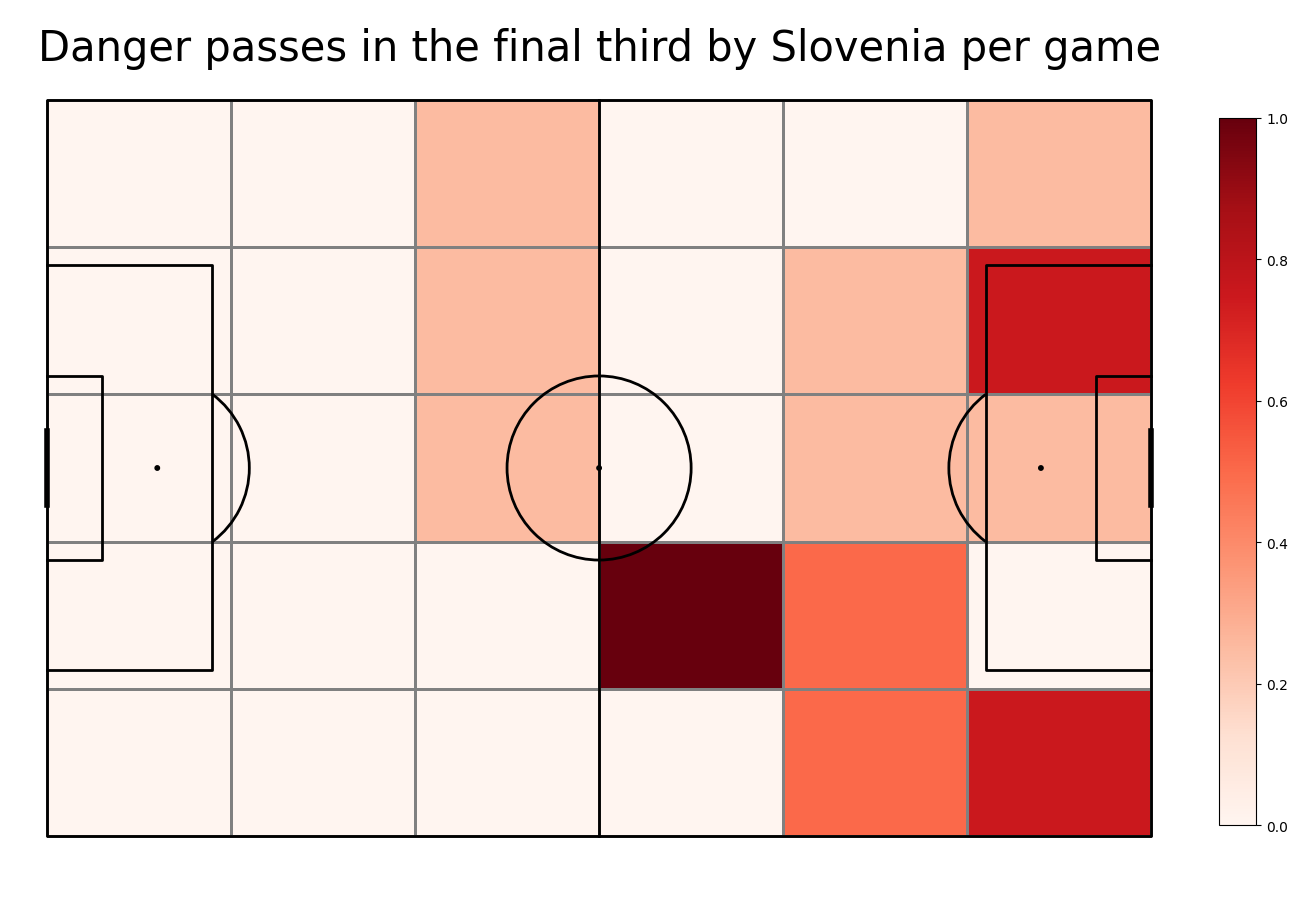

In [21]:
#plot vertical pitch
pitch = Pitch(line_zorder=2, line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
#get the 2D histogram
bin_statistic = pitch.bin_statistic(danger_passes.x, danger_passes.y, statistic='count', bins=(6, 5), normalize=False)
#normalize by number of games
bin_statistic["statistic"] = bin_statistic["statistic"]/no_games
#make a heatmap
pcm  = pitch.heatmap(bin_statistic, cmap='Reds', edgecolor='grey', ax=ax['pitch'])
#legend to our plot
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
fig.suptitle('Danger passes in the final third by ' + team + " per game", fontsize = 30)
plt.show()

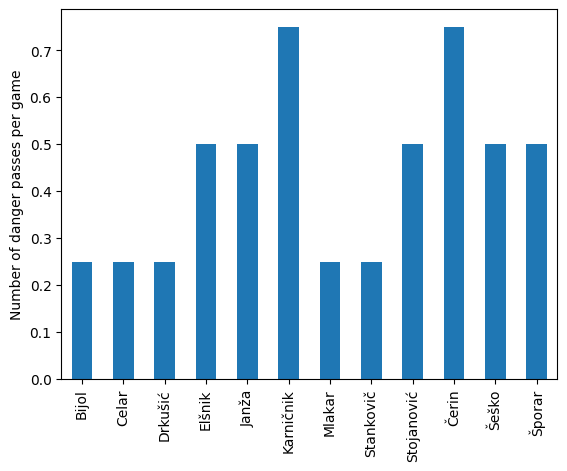

In [22]:
#keep only surnames
danger_passes["player_name"] = danger_passes["player_name"].apply(lambda x: str(x).split()[-1])
#count passes by player and normalize them
pass_count = danger_passes.groupby(["player_name"]).x.count()/no_games
#make a histogram
ax = pass_count.plot.bar(pass_count)
#make legend
ax.set_xlabel("")
ax.set_ylabel("Number of danger passes per game")
plt.show()

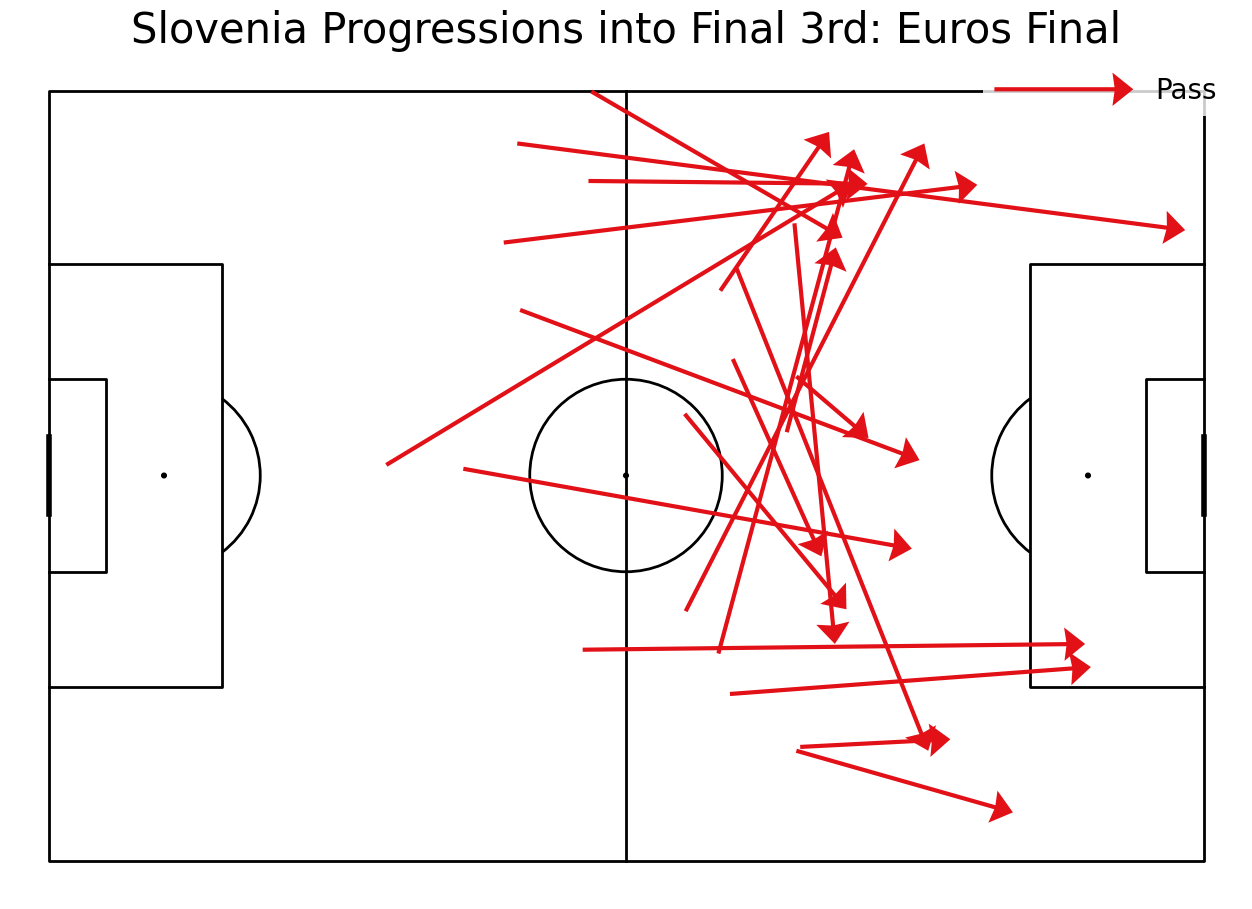

In [23]:
#separate start and end locations from coordinates
# df[['x', 'y']] = df['location'].apply(pd.Series)
# df[['pass_end_x', 'pass_end_y']] = df['pass_end_location'].apply(pd.Series)
# df[['carry_end_x', 'carry_end_y']] = df['carry_end_location'].apply(pd.Series)

#create a variable for the team you want to look into
team="Slovenia"

#filter for only matches that the focus team played in
matches_df = slovenia_games_df[(slovenia_games_df['home_team_country_name'] == team)|(slovenia_games_df['away_team_country_name'] == team)]

#filter for events done by the focus team
#filter by event type to get only passes
#filter for passes that started outside of the final third
#filter for passes that ended in the final third
#filter for completed passes
passes_df=df[(df.team_name==team)&(df.type_name=="Pass")&(df.x<80)&(df.end_x>80)&(df.outcome_name.isna())]

# #keep only accurate passes by England that were not set pieces in this period
# mask_pass = (df.team_name == team) & (df.type_name == "Pass") & (df.outcome_name.isnull()) )
# #keep only necessary columns
# passes_df = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]

#Visualize for a team
pass_colour='#e21017'

#set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_zorder=2, line_color='black')
fig, ax = pitch.draw(figsize=(16, 11),constrained_layout=True, tight_layout=False)
fig.set_facecolor('white')

#plot the passes
pitch.arrows(passes_df.x, passes_df.y,
passes_df.end_x, passes_df.end_y, width=3,
headwidth=8, headlength=5, color=pass_colour, ax=ax, zorder=2, label = "Pass")

#plot the legend
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

#set title of viz
ax_title = ax.set_title(f'{team} Progressions into Final 3rd: Euros Final', fontsize=30,color='black')

In [24]:
#Visualize for a given player
#declare an empty dataframe
player_passes_final_3rd = pd.DataFrame()
player_name=Cerin
for idx in match_ids:
        #open the event data from this game
    df = parser.event(idx)[0]
    player_passes_final_3rd_game=df[(df.player_name ==player_name)&(df.type_name=="Pass")&(df.x<80)&(df.end_x>80)&(df.outcome_name.isna())]
    player_passes_final_3rd = pd.concat([player_passes_final_3rd,player_passes_final_3rd_game], ignore_index = True)


In [25]:
player_passes_final_3rd

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,substitution_replacement_id,substitution_replacement_name,foul_committed_penalty,foul_won_penalty,bad_behaviour_card_id,bad_behaviour_card_name,pass_miscommunication,injury_stoppage_in_chain,pass_goal_assist,shot_deflected
0,a227bc02-7b1d-45ba-8795-9f3db488d32b,202,1,00:04:32.861000,4,32,11,0.842251,3930181,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3ad9b47b-2682-47c4-81a0-96b9f4ec954a,1565,1,00:36:28.468000,36,28,58,1.610029,3930181,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,40562d0c-dcad-44e9-a9e5-8851dc030770,938,1,00:20:04.735000,20,4,38,0.713109,3930170,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ff38ef13-42d1-4bd0-b1da-b0f5191c3c93,2266,2,00:09:13.062000,54,13,91,2.415332,3930170,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,efb79d65-4e1b-433d-8c8f-9e0ca9b640a4,355,1,00:06:50.676000,6,50,10,2.350238,3930162,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,d9d4c056-9885-4b09-b79c-3e6463e9a78f,965,1,00:23:42.434000,23,42,33,1.850895,3930162,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,22ead9a5-da24-4eb8-b5aa-0593aa916d26,1549,1,00:36:40.808000,36,40,54,3.006309,3930162,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,235df2e2-5dc3-4d35-b9ca-177d0ec6fc42,2829,2,00:24:37.206000,69,37,103,1.307551,3930162,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


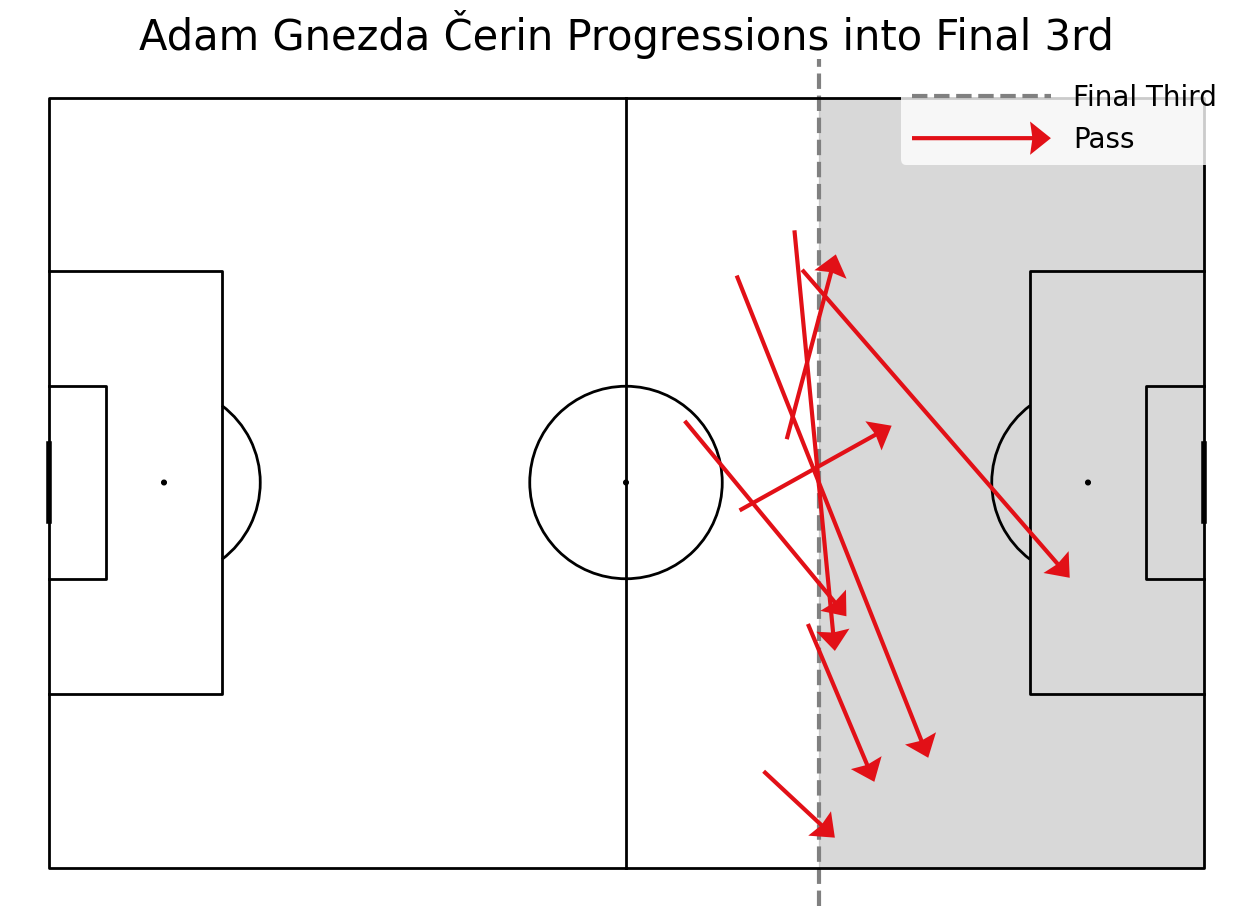

In [26]:

pass_colour='#e21017'

#set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_zorder=2, line_color='black')
fig, ax = pitch.draw(figsize=(16, 11),constrained_layout=True, tight_layout=False)
fig.set_facecolor('white')

# Draw the final third line (assuming x-axis is 0 to 100)
final_third_x = 80  # The start of the final third
ax.axvline(final_third_x, color='grey', linestyle='--', lw=3, zorder=1, label='Final Third')
# Alternatively, you can fill the final third with a light color
ax.fill_betweenx([0, 80], final_third_x, 120, color='grey', alpha=0.3, zorder=0)
#plot the passes
pitch.arrows(player_passes_final_3rd.x, player_passes_final_3rd.y,
player_passes_final_3rd.end_x, player_passes_final_3rd.end_y, width=3,
headwidth=8, headlength=5, color=pass_colour, ax=ax, zorder=2, label = "Pass")

#plot the legend
ax.legend(facecolor='white', handlelength=5, edgecolor='None', fontsize=20, loc='best')

#set title of viz
ax_title = ax.set_title(f'{player_name} Progressions into Final 3rd', fontsize=30,color='black')

# Pass network of 4 games for Comparison

In [27]:

team="Slovenia"

#filter for only matches that the focus team played in
matches_df = slovenia_games_df[(slovenia_games_df['home_team_country_name'] == team)|(slovenia_games_df['away_team_country_name'] == team)]
#declare an empty dataframe
total_events_slovenia = pd.DataFrame()
for idx in match_ids:
    #open the event data from this game
    df = parser.event(idx)[0]
    #keep only accurate passes by England that were not set pieces in this period
    # Concatenate the current DataFrame with the main DataFrame
    total_events_slovenia = pd.concat([total_events_slovenia, df], ignore_index = True)

In [28]:
print(matches_df[['home_team_country_name', 'away_team_country_name', 'match_id']])


   home_team_country_name away_team_country_name  match_id
13               Portugal               Slovenia   3941020
38                England               Slovenia   3930181
43               Slovenia                 Serbia   3930170
47               Slovenia                Denmark   3930162


In [29]:
passes_slovenia = total_events_slovenia.loc[total_events_slovenia['type_name'] == 'Pass'].loc[total_events_slovenia['sub_type_name'] != 'Throw-in'].set_index('id')

In [30]:
# Initialize an empty DataFrame to store the result
df_pass_all = pd.DataFrame()

# Loop through each match_id in the dataset
for match_id in total_events_slovenia['match_id'].unique():
    
    # Filter events for the current match and reset the index for local indexing
    match_events = total_events_slovenia[total_events_slovenia["match_id"] == match_id].reset_index(drop=True)
    print("match id: ", match_id)
    
    # Check if there is any substitution for Slovenia in this match
    if not match_events.loc[(match_events["type_name"] == "Substitution") & (match_events["team_name"] == "Slovenia")].empty:
        # Get the index of the first substitution for Slovenia (local index)
        sub_index = match_events.loc[(match_events["type_name"] == "Substitution") & 
                                     (match_events["team_name"] == "Slovenia")].index[0]
        print("sub index:", sub_index)
        
        # Create a mask for successful Slovenia passes before the first substitution
        mask_Slovenia = (
            (match_events.type_name == 'Pass') & 
            (match_events.team_name == "Slovenia") & 
            (match_events.index < sub_index) & 
            (match_events.outcome_name.isnull()) & 
            (match_events.sub_type_name != "Throw-in")
        )
        
        # Filter the necessary columns
        df_pass = match_events.loc[mask_Slovenia, ['match_id', 'x', 'y', 'end_x', 'end_y', "player_name", "pass_recipient_name"]]
        
        # Adjust so that only the surname of a player is presented
        df_pass["player_name"] = df_pass["player_name"].apply(lambda x: str(x).split()[-1])
        df_pass["pass_recipient_name"] = df_pass["pass_recipient_name"].apply(lambda x: str(x).split()[-1])
        
        # Append the result to the final DataFrame
        df_pass_all = pd.concat([df_pass_all, df_pass])

# The final df_pass_all contains the filtered passes for all matches


match id:  3941020
sub index: 2633
match id:  3930181
sub index: 3069
match id:  3930170
sub index: 2663
match id:  3930162
sub index: 2671


In [31]:
import matplotlib.pyplot as plt

# Initialize a dictionary to store scatter_df and lines_df for each match
scatter_dfs = {}
lines_dfs = {}

# Loop through each match_id and calculate the scatter_df and lines_df for each match
for match_id in df_pass_all['match_id'].unique():
    scatter_df = pd.DataFrame()
    
    # Loop through each player in the current match
    for i, name in enumerate(df_pass_all[df_pass_all["match_id"] == match_id]["player_name"].unique()):
        passx = df_pass_all.loc[(df_pass_all["player_name"] == name) & (df_pass_all["match_id"] == match_id)]["x"].to_numpy()
        recx = df_pass_all.loc[(df_pass_all["pass_recipient_name"] == name) & (df_pass_all["match_id"] == match_id)]["end_x"].to_numpy()
        passy = df_pass_all.loc[(df_pass_all["player_name"] == name) & (df_pass_all["match_id"] == match_id)]["y"].to_numpy()
        recy = df_pass_all.loc[(df_pass_all["pass_recipient_name"] == name) & (df_pass_all["match_id"] == match_id)]["end_y"].to_numpy()
        
        scatter_df.at[i, "player_name"] = name
        # Average position of passes and receptions
        scatter_df.at[i, "x"] = np.mean(np.concatenate([passx, recx]))
        scatter_df.at[i, "y"] = np.mean(np.concatenate([passy, recy]))
        # Number of passes made by the player
        scatter_df.at[i, "no"] = df_pass_all.loc[(df_pass_all["player_name"] == name) & (df_pass_all["match_id"] == match_id)].count().iloc[0]

    # Adjust the circle size based on number of passes
    scatter_df['marker_size'] = (scatter_df['no'] / scatter_df['no'].max() * 1000)
    
    # Store the scatter_df for this match_id
    scatter_dfs[match_id] = scatter_df
    
    # Now count passes between players for the passing network (pair key logic)
    df_pass_match = df_pass_all[df_pass_all["match_id"] == match_id].copy()
    df_pass_match["pair_key"] = df_pass_match.apply(lambda x: "_".join(sorted([x["player_name"], x["pass_recipient_name"]])), axis=1)
    
    # Count passes between player pairs
    lines_df = df_pass_match.groupby("pair_key").x.count().reset_index()
    lines_df.rename({'x':'pass_count'}, axis='columns', inplace=True)
    
    # Apply the pass count threshold (keeping pairs with more than 2 passes)
    lines_df = lines_df[lines_df['pass_count'] > 2]
    
    # Store the lines_df for this match_id
    lines_dfs[match_id] = lines_df



In [32]:
import matplotlib.pyplot as plt
from matplotlib import cm  # for color gradient
from mplsoccer import Pitch
import matplotlib.patches as mpatches  # for creating custom legend

match_opponents = {
    3941020: "Portugal",
    3930181: "England",
    3930170: "Serbia",
    3930162: "Denmark"
}


/var/folders/zs/shjf_6j915n707ks3n6jncwr0000gn/T/ipykernel_53913/1697694971.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Reds')


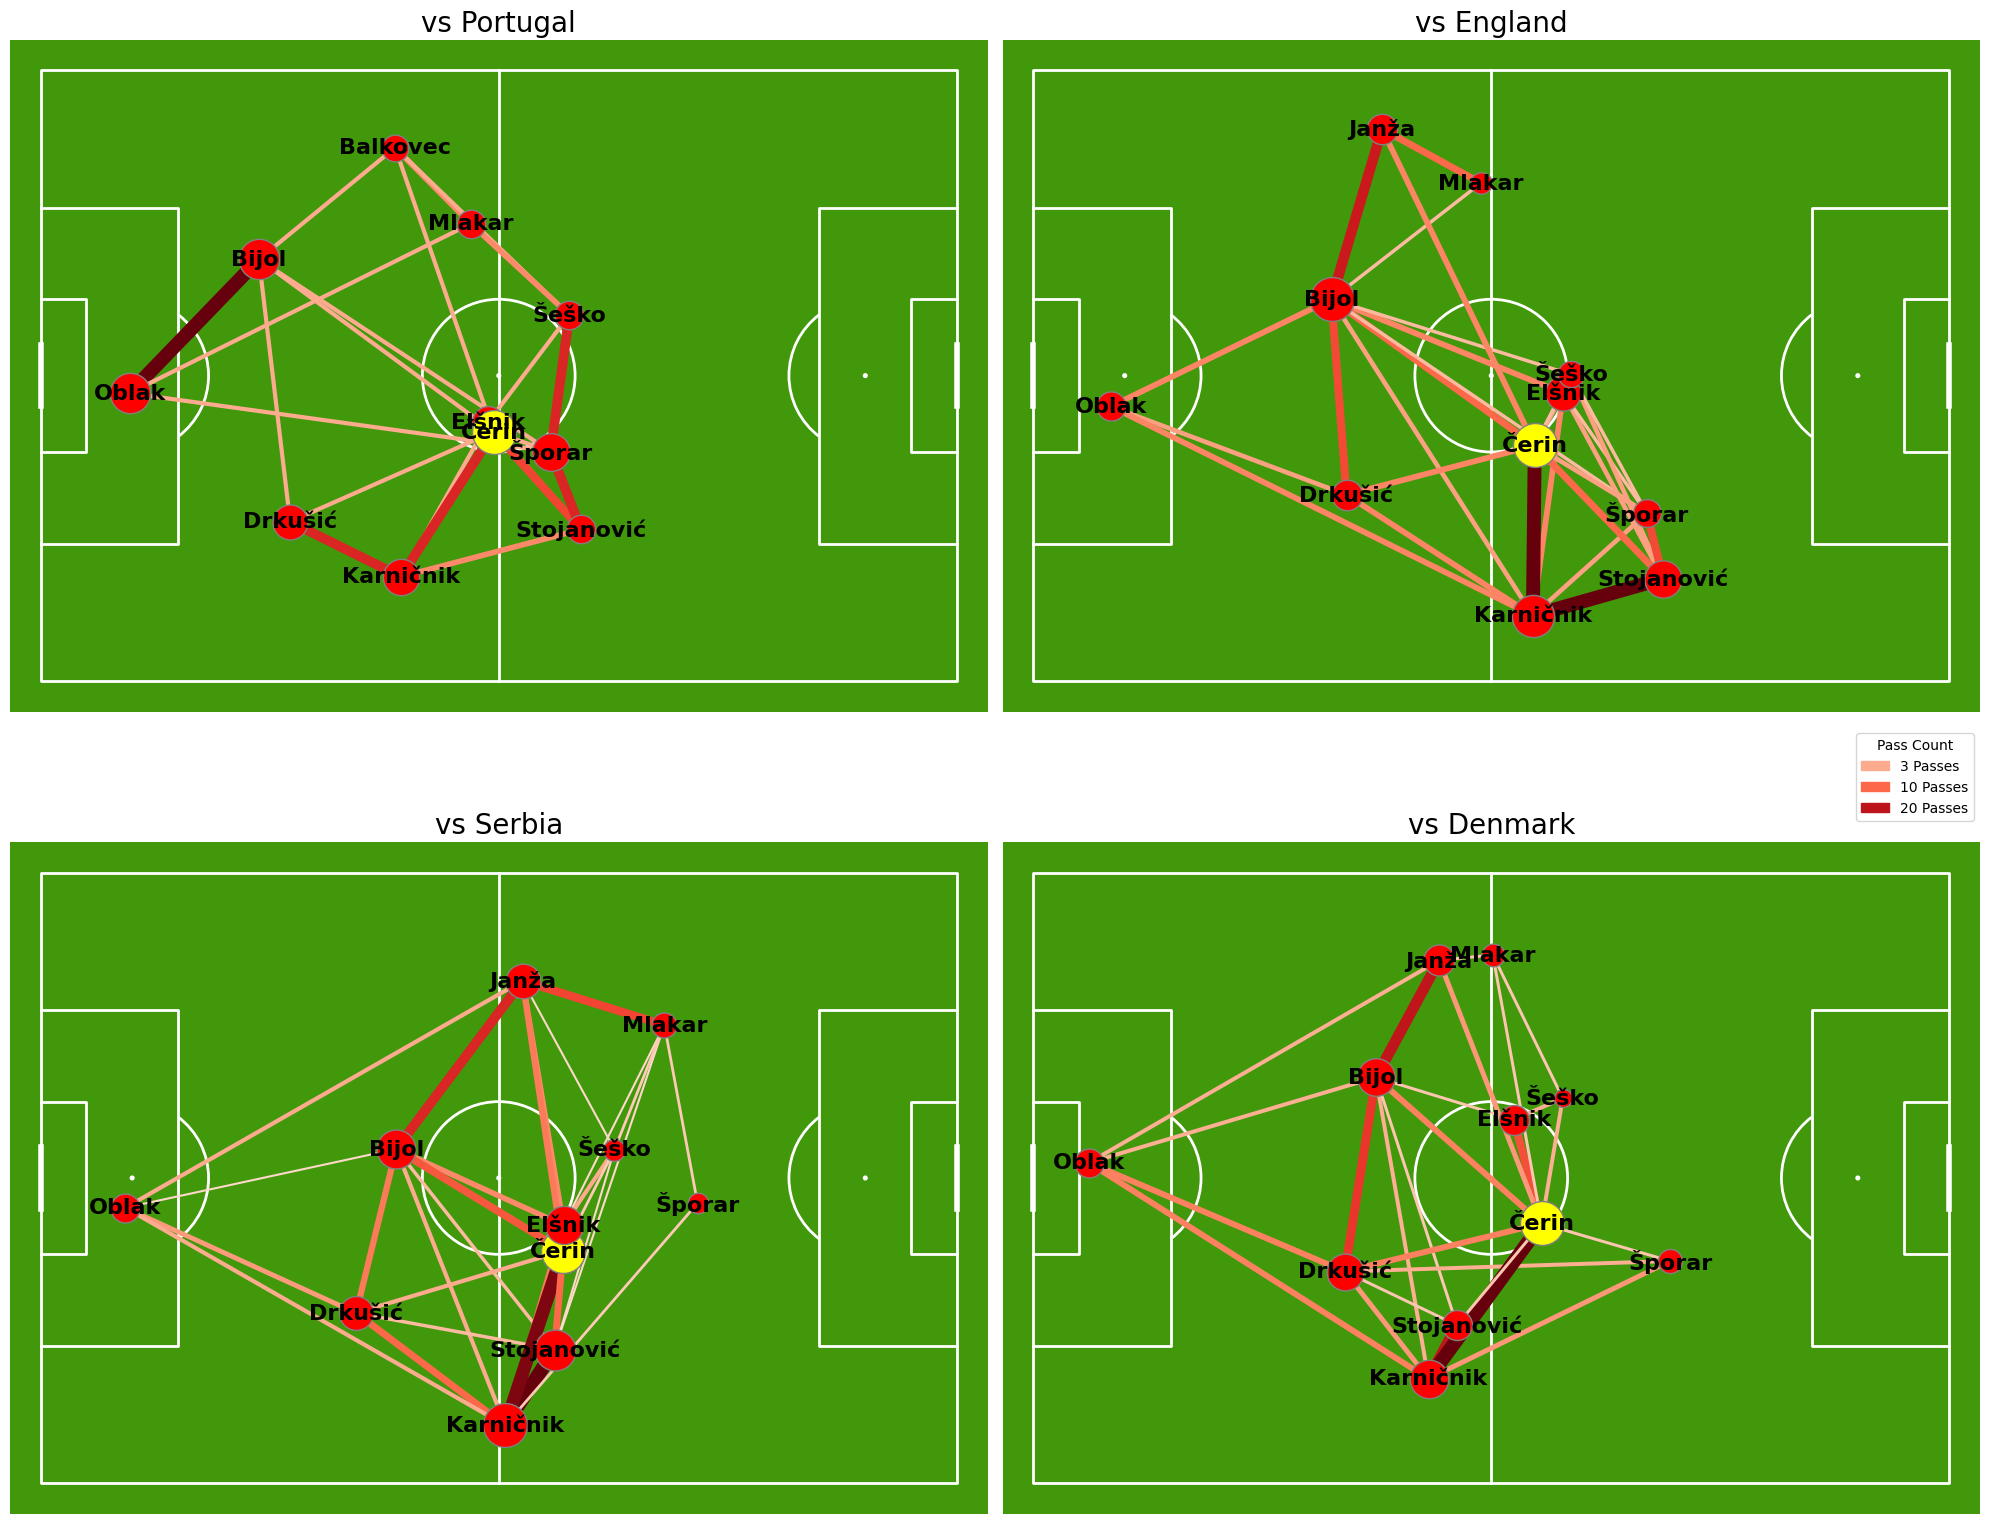

Match 3941020: Slovenia vs Portugal
Match 3930181: Slovenia vs England
Match 3930170: Slovenia vs Serbia
Match 3930162: Slovenia vs Denmark


In [33]:
# Define the colormap (Reds for gradient)
cmap = cm.get_cmap('Reds')
# Now we can plot the networks for each match
# Now we can plot the networks for each match
fig, axes = plt.subplots(2, 2, figsize=(20, 17))  # Create a 2x2 grid for the 4 matches

# Change the background color of the entire figure (outside the pitch)
fig.patch.set_facecolor('#FFFFFF')  # Example background color (light blue)

# Create a legend for line thickness (pass counts)
max_pass_count = max([lines_df['pass_count'].max() for lines_df in lines_dfs.values()])
legend_elements = [
    mpatches.FancyBboxPatch((0, 0), 0.2, 0.05, color=cmap(0.3), label=f'3 Passes', boxstyle="round,pad=0.3", edgecolor='black'),
    mpatches.FancyBboxPatch((0, 0), 0.4, 0.05, color=cmap(0.5), label=f'{int(max_pass_count/2)} Passes', boxstyle="round,pad=0.3", edgecolor='black'),
    mpatches.FancyBboxPatch((0, 0), 0.6, 0.05, color=cmap(0.8), label=f'{max_pass_count} Passes', boxstyle="round,pad=0.3", edgecolor='black'),
]

for ax, match_id in zip(axes.flat, scatter_dfs.keys()):
    scatter_df = scatter_dfs[match_id]
    lines_df = lines_dfs[match_id]
    
    # Create a pitch with a green background
    pitch = Pitch(pitch_color='#41980a', line_color='white')
    pitch.draw(ax=ax)
    
    # Plot each player's position on the pitch
    for i, row in scatter_df.iterrows():
        # Highlight Čerin with a different color (e.g., yellow)
        if row['player_name'] == "Čerin":
            pitch.scatter(row['x'], row['y'], s=row['marker_size'], color='yellow', edgecolors='grey', linewidth=1, alpha=1, ax=ax, zorder=3)
        else:
            pitch.scatter(row['x'], row['y'], s=row['marker_size'], color='red', edgecolors='grey', linewidth=1, alpha=1, ax=ax, zorder=3)
    
    # Annotate player names
    for i, row in scatter_df.iterrows():
        pitch.annotate(row['player_name'], xy=(row['x'], row['y']), c='black', va='center', ha='center', weight='bold', size=16, ax=ax, zorder=4)
    
    # Plot the pass lines between players for the current match
    for i, row in lines_df.iterrows():
        player1, player2 = row["pair_key"].split("_")
        
        # Get player positions from scatter_df
        player1_x = scatter_df.loc[scatter_df["player_name"] == player1]["x"].iloc[0]
        player1_y = scatter_df.loc[scatter_df["player_name"] == player1]["y"].iloc[0]
        player2_x = scatter_df.loc[scatter_df["player_name"] == player2]["x"].iloc[0]
        player2_y = scatter_df.loc[scatter_df["player_name"] == player2]["y"].iloc[0]
        
        # Adjust line width based on pass count
        line_width = (row["pass_count"] / lines_df["pass_count"].max() * 10)
        
        # Normalize the pass count for color intensity (between 0 and 1)
        color_intensity = row["pass_count"] / lines_df["pass_count"].max()
        
        # Get the color from the colormap based on the normalized value
        line_color = cmap(color_intensity)
        
        # Plot the lines between players with gradient color
        pitch.lines(player1_x, player1_y, player2_x, player2_y, alpha=1, lw=line_width, color=line_color, ax=ax, zorder=2)
    
    # Update title with match opponent from dictionary
    opponent = match_opponents[match_id]
    ax.set_title(f"vs {opponent}", fontsize=20)

# Adjust layout to reduce the space between rows and columns
plt.tight_layout()
#plt.subplots_adjust(hspace=0.01, wspace=0.02)  # Reduce vertical and horizontal space

# Add a legend for the line thickness, and position it in the center of the plot
fig.legend(handles=legend_elements, loc='center', title="Pass Count", bbox_to_anchor=(0.96, 0.5), frameon=True)

# Show the plot
plt.show()

# Print to check which team Slovenia is playing against for each match
for match_id in scatter_dfs.keys():
    print(f"Match {match_id}: Slovenia vs {match_opponents[match_id]}")





In [34]:
#get list of games by our team, either home or away
euro_match_ids = df_match["match_id"].tolist()
#calculate number of games
no_games = len(euro_match_ids)

### store play time per player

In [35]:
# Initialize an empty DataFrame to store all events across matches
total_events_euro2024 = pd.DataFrame()

# Loop over each match ID and retrieve the event data for Slovenia (or other conditions you want)
for idx in euro_match_ids:
    # Get the event data for the match (assuming parser.event() retrieves event data for a match)
    df = parser.event(idx)[0]  # Assuming [0] extracts the DataFrame from the returned tuple
    
    # Concatenate the current match's events with the total_events DataFrame
    total_events_euro2024 = pd.concat([total_events_euro2024, df], ignore_index=True)

# Now total_events contains all events from all matches
# Initialize an empty DataFrame to store total playing time per player
total_playing_time = pd.DataFrame()

# Loop over each match ID and calculate total playing time
for idx in euro_match_ids:
    # Get the event data for the match
    df = parser.event(idx)[0]  # Assuming [0] extracts the DataFrame from the returned tuple
    
    # We assume each player starts at minute 0 and ends at the final whistle or substitution
    # Collect minutes played by each player
    for player in df.player_name.unique():
        # Filter all events related to the player
        player_events = df[df.player_name == player]
        
        # Find the max minute played by the player
        max_minute = player_events['minute'].max()
        
        # If there's a substitution event, consider the substitution time as the end time
        if 'substitution' in player_events['type_name'].values:
            substitution_time = player_events[player_events.type_name == 'Substitution']['minute'].min()
            max_minute = min(max_minute, substitution_time)
        
        # Accumulate total playing time for this player
        total_playing_time = pd.concat([total_playing_time, pd.DataFrame({'player_name': [player], 'minutes_played': [max_minute]})], ignore_index=True)

# Now aggregate total playing time per player across all matches
total_playing_time = total_playing_time.groupby('player_name')['minutes_played'].sum().reset_index()

# Filter out players who played less than 150 minutes
filtered_players = total_playing_time[total_playing_time.minutes_played > 150]


In [36]:
filtered_players.head()

,player_name,minutes_played
0,Abdülkerim Bardakcı,373.0
1,Adam Buksa,153.0
2,Adam Gnezda Čerin,396.0
4,Adam Obert,191.0
5,Adrien Rabiot,377.0


## Danger Passes per Player

In [37]:

# Initialize an empty DataFrame to store all danger passes across matches and players
all_danger_passes = pd.DataFrame()

# Loop over each match ID and process each match's events
for idx in euro_match_ids:
    # Get the event data for the match
    df = parser.event(idx)[0]  # Assuming [0] extracts the DataFrame from the returned tuple

    # Initialize an empty DataFrame for danger passes in this match
    danger_passes = pd.DataFrame()

    # Loop through the periods (1st and 2nd half)
    for period in [1, 2, 3 ,4]:
        # Keep only accurate passes that were not set pieces in this period, for filtered players only
        mask_pass = (
            (df.type_name == "Pass") &
            (df.outcome_name.isnull()) &
            (df.period == period) &
            (df.sub_type_name.isnull()) &
            (df.player_name.isin(filtered_players['player_name']))
        )
        # Keep only necessary columns
        passes = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]

        # Keep only shots in this period with xG > 0.06, for all teams
        mask_shot = (
            (df.type_name == "Shot") &
            (df.period == period) &
            (df.shot_statsbomb_xg > 0.06)
        )
        # Keep only necessary columns
        shots = df.loc[mask_shot, ["minute", "second"]]

        # Convert time to seconds for shots
        shot_times = shots['minute']*60 + shots['second']
        shot_window = 15  # Window around the shot to look for passes

        # Find the start of the window
        shot_start = shot_times - shot_window
        shot_start = shot_start.apply(lambda i: i if i > 0 else (period-1)*45*60)  # Avoid negative shot starts

        # Convert time to seconds for passes
        pass_times = passes['minute']*60 + passes['second']

        # Check if each pass is in any of the windows for this half
        pass_to_shot = pass_times.apply(lambda x: True in ((shot_start < x) & (x < shot_times)).unique())

        # Keep only danger passes
        danger_passes_period = passes.loc[pass_to_shot]

        # Concatenate the current period's danger passes with the overall match danger passes
        danger_passes = pd.concat([danger_passes, danger_passes_period], ignore_index=True)

    # Add the danger passes for this match to the overall dataset
    all_danger_passes = pd.concat([all_danger_passes, danger_passes], ignore_index=True)

# Now we can calculate the number of danger passes for each player
danger_pass_count = all_danger_passes.groupby('player_name').size().reset_index(name='danger_pass_count')

# Merge with total playing time to calculate danger passes per 90 minutes
danger_pass_count = danger_pass_count.merge(total_playing_time, on='player_name')

# Calculate danger passes per 90 minutes
danger_pass_count['danger_passes_per_90'] = (danger_pass_count['danger_pass_count'] / danger_pass_count['minutes_played']) * 90

# Sort by danger passes per 90 minutes in descending order for ranking
danger_pass_count = danger_pass_count.sort_values(by='danger_passes_per_90', ascending=False)


In [38]:
danger_pass_count

,player_name,danger_pass_count,minutes_played,danger_passes_per_90
299,Toni Kroos,28,485.0,5.195876
248,Pedro González López,8,186.0,3.870968
141,Joshua Kimmich,19,489.0,3.496933
58,David Jurásek,6,160.0,3.375000
83,Fabián Ruiz Peña,21,569.0,3.321617
...,...,...,...,...
123,Jan Oblak,1,404.0,0.222772
218,Muhammed Kerem Aktürkoğlu,1,436.0,0.206422
52,Conor Gallagher,1,445.0,0.202247
51,Cole Palmer,1,518.0,0.173745


In [39]:

# Display the results
# import ace_tools as tools; tools.display_dataframe_to_user(name="Danger Passes per 90 Minutes", dataframe=danger_pass_count)


In [40]:
from statsbombpy import sb
from datetime import timedelta

In [41]:
# list of matches in that competition
mat = sb.matches(competition_id=55, season_id=282)


In [42]:
starting_xi = pd.DataFrame()
for match_id in mat.match_id.unique():
    # Load the event data for the match
    events = sb.events(match_id=match_id)
    
    starting_xi = pd.concat([starting_xi, events[events['type'] == 'Starting XI']], ignore_index=True)

In [43]:
reduced_df = total_events_euro2024.loc[(
    (total_events_euro2024.type_name.isin(['Starting XI','Substitution', 'Half End'])) | 
    (total_events_euro2024.foul_committed_card_name.isin(['Red Card','Second Yellow'])))]

In [44]:
import datetime
import pandas as pd

# Convert time to string format if it's of type datetime.time
reduced_df['timestamp'] = reduced_df['timestamp'].apply(lambda x: f"{x.hour}:{x.minute}:{x.second}" if isinstance(x, datetime.time) else x)

# Convert the modified column to timedelta
reduced_df['timestamp'] = pd.to_timedelta(reduced_df['timestamp'])

/var/folders/zs/shjf_6j915n707ks3n6jncwr0000gn/T/ipykernel_53913/1976717493.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced_df['timestamp'] = reduced_df['timestamp'].apply(lambda x: f"{x.hour}:{x.minute}:{x.second}" if isinstance(x, datetime.time) else x)
/var/folders/zs/shjf_6j915n707ks3n6jncwr0000gn/T/ipykernel_53913/1976717493.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced_df['timestamp'] = pd.to_timedelta(reduced_df['timestamp'])


In [45]:
# remove all columns where ALL values are None 
reduced_df = reduced_df.dropna(axis=1, how="all")
reduced_df = reduced_df.sort_values(by=['match_id','period','timestamp'])

In [46]:
match_df = pd.DataFrame()
# Loop through all matches of the season
for match_id in reduced_df.match_id.unique():
    # Initialize an empty dict to store the game time
    players_match_dict = {}
    # Reduce to events of this match
    match_df_ = reduced_df[reduced_df.match_id == match_id]
    match_df = pd.concat([match_df, match_df_], ignore_index=True)

In [47]:
# Calculate total game time
period_1 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 1)].iloc[0].timestamp
period_2 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 2)].iloc[0].timestamp
total_game_time = period_1 + period_2

In [48]:
# Initialize an empty DataFrame to store all players’ data
players_df = pd.DataFrame(columns=['player', 'playtime', 'match_id'])
# Create a DataFrame for the current match
players_match_df = pd.DataFrame(players_match_dict.items(), columns=['player', 'playtime'])

    # Initialize an empty dict to store the game time
players_match_dict = {}

# Loop through all matches of the season
for match_id_index in mat.index:

    # Get the current match_id based on the iteration
    match_id = mat.loc[match_id_index, 'match_id']  # Assuming 'match_id' is a column in 'mat'
    # Get the initial lineup
    lineup = starting_xi[starting_xi.type == 'Starting XI'].iloc[match_id_index].tactics


    players_match_df['match_id'] = starting_xi[starting_xi.type == 'Starting XI'].iloc[match_id_index].match_id
    # Append the current match DataFrame to the main DataFrame
    players_df = pd.concat([players_df, players_match_df], ignore_index=True)

        # Calculate total game time
    period_1 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 1)].iloc[match_id_index].timestamp
    period_2 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 2)].iloc[match_id_index].timestamp
    total_game_time = period_1 + period_2

          # Initialize player in match dictionary
    for player in lineup['lineup']:
        players_match_dict[player['player']['name']] = total_game_time



In [49]:
# Convert timedelta to minutes
players_df['playtime_minutes'] = players_df['playtime'].apply(lambda x: x.total_seconds() / 60)

In [50]:
players_df.groupby(['player'])['playtime_minutes'].sum().sort_values(ascending=False)

Series([], Name: playtime_minutes, dtype: object)

In [51]:
# Initialize an empty DataFrame to store all events for Slovenia
total_events_slovenia = pd.DataFrame()

# Loop over each match ID and retrieve the event data for Slovenia
for idx in slovenia_games_df.match_id:
    # Get the event data for the match (assuming parser.event() retrieves event data for a match)
    df = parser.event(idx)[0]  # Assuming [0] extracts the DataFrame from the returned tuple
    total_events_slovenia = pd.concat([total_events_slovenia, df], ignore_index=True)


In [52]:
from statsbombpy import sb
import pandas as pd
import datetime
from datetime import timedelta

In [53]:
# Convert time to string format if it's of type datetime.time
reduced_df['timestamp'] = reduced_df['timestamp'].apply(lambda x: f"{x.hour}:{x.minute}:{x.second}" if isinstance(x, datetime.time) else x)

# Convert the modified column to timedelta
reduced_df['timestamp'] = pd.to_timedelta(reduced_df['timestamp'])

In [54]:
players_df.groupby(['player'])['playtime_minutes'].sum().sort_values(ascending=False)

Series([], Name: playtime_minutes, dtype: object)

In [55]:
# Group by 'player', sum the 'playtime_minutes', and sort in descending order
total_playtime_by_player = players_df.groupby(['player'])['playtime_minutes'].sum().sort_values(ascending=False)

# Display the result
print(total_playtime_by_player)

Series([], Name: playtime_minutes, dtype: object)


In [56]:
import pandas as pd
from datetime import timedelta

def calculate_total_playtime(games_df):

    # Initialize an empty DataFrame to store all events for Slovenia
    total_events = pd.DataFrame()

    # Loop over each match ID and retrieve the event data for Slovenia
    for idx in games_df.match_id:
        # Get the event data for the match (assuming parser.event() retrieves event data for a match)
        df = parser.event(idx)[0]  # Assuming [0] extracts the DataFrame from the returned tuple
        total_events = pd.concat([total_events, df], ignore_index=True)

    # Initialize an empty DataFrame to store all players’ data
    players_df = pd.DataFrame(columns=['player', 'playtime', 'match_id'])

    # Filter events for specific types and team
    reduced_df = total_events.loc[
        ((total_events.type_name.isin(['Starting XI', 'Substitution', 'Half End'])) |
        (total_events.foul_committed_card_name.isin(['Red Card', 'Second Yellow'])))
    ]

    # Convert time to string format if it's of type datetime.time
    reduced_df['timestamp'] = reduced_df['timestamp'].apply(lambda x: f"{x.hour}:{x.minute}:{x.second}" if isinstance(x, datetime.time) else x)

    # Convert the modified column to timedelta
    reduced_df['timestamp'] = pd.to_timedelta(reduced_df['timestamp'])

    # Sort the DataFrame by match_id, period, and timestamp
    reduced_df = reduced_df.sort_values(by=['match_id', 'period', 'timestamp'])

    # Loop through all matches
    for match_id in games_df.match_id:
        # Initialize an empty dict to store the game time
        players_match_dict = {}

        # Reduce to events of this match
        match_df = reduced_df[reduced_df.match_id == match_id]

        # Calculate total game time
        period_1 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 1)].iloc[0].timestamp
        period_2 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 2)].iloc[0].timestamp
        
        # Handle extra time periods
        period_3 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 3)].iloc[0].timestamp if any(match_df.period == 3) else timedelta(0)
        period_4 = match_df[(match_df.type_name == 'Half End') & (match_df.period == 4)].iloc[0].timestamp if any(match_df.period == 4) else timedelta(0)

        total_game_time = period_1 + period_2 + period_3 + period_4

        # Load the event data for the match
        events = sb.events(match_id=match_id)

        # Process starting lineups
        home_lineup = events[events.type == 'Starting XI'].iloc[0].tactics
        away_lineup = events[events.type == 'Starting XI'].iloc[1].tactics

        for player in home_lineup['lineup']:
            players_match_dict[player['player']['name']] = total_game_time
        for player in away_lineup['lineup']:
            players_match_dict[player['player']['name']] = total_game_time

        # Handle Substitutions and Red Cards
        for event in match_df.itertuples():
            if event.type_name == 'Substitution':
                player_subbed_out = event.player_name
                player_subbed_in = event.substitution_replacement_name
                # Calculate playtime for substituted players
                if event.period == 1:
                    minutes_played = event.timestamp
                    players_match_dict[player_subbed_out] = minutes_played
                elif event.period == 2:
                    minutes_played = period_1 + event.timestamp
                    players_match_dict[player_subbed_out] = minutes_played
                elif event.period == 3:
                    minutes_played = period_1 + period_2 + event.timestamp
                    players_match_dict[player_subbed_out] = minutes_played
                elif event.period == 4:
                    minutes_played = period_1 + period_2 + period_3 + event.timestamp
                    players_match_dict[player_subbed_out] = minutes_played

                if event.period == 1:
                    minutes_played = total_game_time - event.timestamp - period_1
                    players_match_dict[player_subbed_in] = minutes_played
                elif event.period == 2:
                    minutes_played = total_game_time - event.timestamp
                    players_match_dict[player_subbed_in] = minutes_played
                elif event.period == 3:
                    minutes_played = total_game_time - (period_1 + period_2 + event.timestamp)
                    players_match_dict[player_subbed_in] = minutes_played
                elif event.period == 4:
                    minutes_played = total_game_time - (period_1 + period_2 + period_3 + event.timestamp)
                    players_match_dict[player_subbed_in] = minutes_played

            elif event.foul_committed_card_name in ['Red Card', 'Second Yellow']:
                player_with_red_card = event.player_name
                if event.period == 1:
                    players_match_dict[player_with_red_card] = event.timestamp
                elif event.period == 2:
                    players_match_dict[player_with_red_card] = event.timestamp + period_1
                elif event.period == 3:
                    players_match_dict[player_with_red_card] = event.timestamp + period_1 + period_2
                elif event.period == 4:
                    players_match_dict[player_with_red_card] = event.timestamp + period_1 + period_2 + period_3

        # Create a DataFrame for the current match
        players_match_df = pd.DataFrame(players_match_dict.items(), columns=['player_name', 'playtime'])
        players_match_df['match_id'] = match_id

        # Convert timedelta to minutes
        players_match_df['playtime_minutes'] = players_match_df['playtime'].apply(lambda x: x.total_seconds() / 60)

        # Append to the main DataFrame
        players_df = pd.concat([players_df, players_match_df], ignore_index=True)

    # Group by player and sum the playtime
    total_playtime_by_player = players_df.groupby(['player_name'])['playtime_minutes'].sum().sort_values(ascending=False)

    return total_playtime_by_player


In [57]:
#opening data using match method
all_euro2024_matches_df = parser.match(competition_id=55, season_id=282)

In [58]:
total_playtime_by_player_all = calculate_total_playtime(all_euro2024_matches_df)

/var/folders/zs/shjf_6j915n707ks3n6jncwr0000gn/T/ipykernel_53913/2066719472.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced_df['timestamp'] = reduced_df['timestamp'].apply(lambda x: f"{x.hour}:{x.minute}:{x.second}" if isinstance(x, datetime.time) else x)
/var/folders/zs/shjf_6j915n707ks3n6jncwr0000gn/T/ipykernel_53913/2066719472.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reduced_df['timestamp'] = pd.to_timedelta(reduced_df['timestamp'])
/var/folders/zs/shjf_6j915n707ks3n6jncwr0000gn/

In [59]:
total_playtime_by_player_all

player_name
John Stones                     736.683333
Jordan Pickford                 736.683333
Kyle Walker                     736.683333
Declan Rice                     736.683333
Jude Bellingham                 711.733333
                                   ...    
Filip Kostić                     43.000000
Ryan Porteous                    41.116667
Vasile Mogoș                     37.816667
Denis Lemi Zakaria Lako Lado     23.450000
Ľubomír Tupta                    12.833333
Name: playtime_minutes, Length: 493, dtype: float64

### Danger passes function

In [60]:
import pandas as pd

def identify_danger_passes(games_df, xg_threshold=0.06, shot_window=15):
    """
    Identifies danger passes that occur within a specified time window before a high-xG shot, 
    and includes the nationality of the players in the output.

    Parameters:
    - games_df (DataFrame): A DataFrame containing the game information (with match IDs).
    - xg_threshold (float): The xG threshold to classify a shot as dangerous. Default is 0.06.
    - shot_window (int): The number of seconds before a shot to classify a pass as dangerous. Default is 15 seconds.

    Returns:
    - danger_passes (DataFrame): A DataFrame containing all identified danger passes with player nationality.
    - pass_count (DataFrame): A DataFrame with the count of danger passes normalized by the number of games, 
      including player nationality.
    """
    
    # Declare an empty dataframe to store all danger passes
    danger_passes = pd.DataFrame()
    
    # Loop through all match IDs
    for idx in games_df.match_id:
        # Open the event data for this game
        df = parser.event(idx)[0]
        
        # Extract unique team names from the event data
        teams = df['team_name'].unique()
        
        # Loop through both teams (home and away)
        for team in teams:
            # Get the nationality from the team name using the dictionary
            nationality = team
            
            # Loop through all periods of the match (1st, 2nd, and extra time periods)
            for period in [1, 2, 3, 4]:
                # Keep only accurate passes by the specified team that were not set pieces in this period
                mask_pass = (df.team_name == team) & (df.type_name == "Pass") & (df.outcome_name.isnull()) & (df.period == period) & (df.sub_type_name.isnull())
                # Keep only necessary columns for passes
                passes = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]
                
                # Add nationality column to passes
                passes['nationality'] = nationality
                
                # Keep only shots by the specified team in this period with xG greater than the threshold
                mask_shot = (df.team_name == team) & (df.type_name == "Shot") & (df.period == period) & (df.shot_statsbomb_xg > xg_threshold)
                # Keep only necessary columns for shots
                shots = df.loc[mask_shot, ["minute", "second"]]
                
                # Convert shot times to seconds
                shot_times = shots['minute']*60 + shots['second']
                
                # Calculate the start of the window (shot_window seconds before the shot)
                shot_start = shot_times - shot_window
                # Ensure no negative shot start times
                shot_start = shot_start.apply(lambda i: i if i > 0 else (period-1) * 45 * 60)
                
                # Convert pass times to seconds
                pass_times = passes['minute']*60 + passes['second']
                
                # Check if the pass occurred within any of the shot windows for this half
                pass_to_shot = pass_times.apply(lambda x: True in ((shot_start < x) & (x < shot_times)).unique())
                
                # Keep only passes that happened within the danger window (danger passes)
                danger_passes_period = passes.loc[pass_to_shot]
                
                # Concatenate danger passes from this period to the overall dataframe
                danger_passes = pd.concat([danger_passes, danger_passes_period], ignore_index=True)
    
    # Count danger passes by player and nationality
    pass_count = danger_passes.groupby(["player_name", "nationality"])["x"].count().reset_index()

    # Rename the count column for clarity
    pass_count = pass_count.rename(columns={"x": "danger_pass_count"})
    
    return danger_passes, pass_count


In [61]:
danger_passes_all, danger_pass_count_all = identify_danger_passes(all_euro2024_matches_df)


In [62]:

danger_pass_count_df = danger_pass_count_all.reset_index()
# Convert playtime Series to DataFrame
total_playtime_df = total_playtime_by_player_all.rename("playtime_minutes").reset_index()

# Merging them on 'player_name'
player_stats_all = pd.merge(danger_pass_count_df, total_playtime_df, on='player_name', how='left')
# Calculate danger passes per 90 minutes
player_stats_all['danger_passes_per_90'] = (player_stats_all['danger_pass_count'] / player_stats_all['playtime_minutes']) * 90
player_stats_all


,index,player_name,nationality,danger_pass_count,playtime_minutes,danger_passes_per_90
0,0,Abdülkerim Bardakcı,Turkey,4,389.350000,0.924618
1,1,Adam Gnezda Čerin,Slovenia,3,415.366667,0.650028
2,2,Adam Hložek,Czech Republic,2,118.033333,1.524993
3,3,Adrien Rabiot,France,11,388.083333,2.550998
4,4,Alejandro Baena Rodríguez,Spain,1,129.383333,0.695607
...,...,...,...,...,...,...
333,333,İlkay Gündoğan,Germany,6,407.883333,1.323908
334,334,İsmail Yüksek,Turkey,1,207.533333,0.433665
335,335,Ľubomír Tupta,Slovakia,1,12.833333,7.012987
336,336,Žan Celar,Slovenia,1,218.400000,0.412088


### Interceptions

In [63]:
import pandas as pd

def calculate_total_interceptions(all_euro2024_matches_df):
    """
    Calculates the total interceptions by player across all matches in the provided matches DataFrame.

    Parameters:
    - all_euro2024_matches_df (DataFrame): DataFrame containing match IDs.
    - sb: The StatsBomb event fetching method (e.g., sb.events()).
    - interceptions_win (list): A list of possible interception outcomes.

    Returns:
    - total_interceptions_by_player (DataFrame): DataFrame containing the total interceptions by each player across all matches.
    """
    
    # Initialize an empty DataFrame to store interceptions by player across all games
    all_interceptions = pd.DataFrame()
    interceptions_win = ["Success", "Won", "Success In Play", "Success Out"] 

    # Loop through each match in the input DataFrame
    for match_id in all_euro2024_matches_df['match_id']:
        
        # Fetch event data for the current match
        events_df = sb.events(match_id=match_id)  # Assuming 'sb.events()' fetches event data for a given match
        
        # Filter the events for interceptions where the interception outcome is in interceptions_win
        interceptions_df = events_df[events_df['interception_outcome'].isin(interceptions_win)]
        
        # Count interceptions by player for the current match
        interceptions_by_player = interceptions_df.groupby('player').size().reset_index(name='interceptions')
        
        # Add match_id to the DataFrame for tracking which match these interceptions came from
        interceptions_by_player['match_id'] = match_id
        
        # Concatenate the current match interceptions to the overall DataFrame
        all_interceptions = pd.concat([all_interceptions, interceptions_by_player], ignore_index=True)

    # Now aggregate the total interceptions by player across all matches
    total_interceptions_by_player = all_interceptions.groupby('player')['interceptions'].sum().reset_index()
    total_interceptions_by_player = total_interceptions_by_player.rename(columns={'player': 'player_name'})
    
    return total_interceptions_by_player


In [64]:
# Calculate total interceptions for all players
total_interceptions_by_player = calculate_total_interceptions(all_euro2024_matches_df)
# Merge the two DataFrames based on the 'player_name' column
player_stats_all_interceptions= pd.merge(player_stats_all, total_interceptions_by_player[['player_name', 'interceptions']], on='player_name', how='left')
player_stats_all_interceptions['interceptions_per_90'] = (player_stats_all_interceptions['interceptions'] / player_stats_all['playtime_minutes']) * 90

In [65]:
# Filter the DataFrame for players with nationality 'Slovenia'
slovenian_players = player_stats_all_interceptions[player_stats_all['nationality'] == 'Slovenia']

### Pass Accuracy

In [66]:
def calculate_pass_accuracy_for_all_matches(matches_df_):
    """
    Calculate pass accuracy for each player across all matches.

    Parameters:
    - all_euro2024_matches_df (DataFrame): DataFrame containing match IDs.
    - sb: The StatsBomb event fetching method (e.g., sb.events()).

    Returns:
    - pass_accuracy_df (DataFrame): DataFrame containing total passes, successful passes, and pass accuracy for each player across all matches.
    """
    
    # Initialize an empty DataFrame to store passes for all players across all matches
    all_passes = pd.DataFrame()

    # Loop through each match in the matches DataFrame
    for match_id in matches_df_['match_id']:
        
        events_df = parser.event(match_id)[0]
        # Fetch the event data for the current match
        #events_df = sb.events(match_id=match_id)  # Assuming 'sb.events()' fetches event data
        
        # Filter the DataFrame to include only pass events
        passes_df = events_df[events_df['type_name'] == 'Pass']
        
        # Use .loc to add match_id to track the source of each pass event
        passes_df.loc[:, 'match_id'] = match_id
        
        # Concatenate the pass data for this match to the overall DataFrame
        all_passes = pd.concat([all_passes, passes_df], ignore_index=True)

    # After processing all matches, calculate total and successful passes by player across all matches
    total_passes_by_player = all_passes.groupby('player_name').size().reset_index(name='total_passes')
    successful_passes_by_player = all_passes[all_passes['outcome_name'].isnull()].groupby('player_name').size().reset_index(name='successful_passes')
    
    # Merge total passes and successful passes into one DataFrame
    pass_accuracy_df = pd.merge(total_passes_by_player, successful_passes_by_player, on='player_name', how='left')
    
    # Calculate pass accuracy
    pass_accuracy_df['pass_accuracy'] = (pass_accuracy_df['successful_passes'] / pass_accuracy_df['total_passes']) * 100
    
    return pass_accuracy_df


In [67]:
# Calcualte Pass Accuracy for all players
pass_accuracy_df = calculate_pass_accuracy_for_all_matches(all_euro2024_matches_df)
player_stats_all_with_pass = pd.merge(player_stats_all_interceptions, pass_accuracy_df, on='player_name', how='left')


### Passes in the Final third

In [68]:
passes_df=df[(df.team_name==team)&(df.type_name=="Pass")&(df.x<80)&(df.end_x>80)&(df.outcome_name.isna())]

In [69]:
def calculate_successful_final_third_passes(matches_df_):
    """
    Calculate the number of successful passes into the final third for each player across all matches.

    Parameters:
    - all_euro2024_matches_df (DataFrame): DataFrame containing match IDs.
    - sb: The StatsBomb event fetching method (e.g., sb.events()).

    Returns:
    - final_third_passes_df (DataFrame): DataFrame containing the number of successful passes into the final third for each player across all matches.
    """
    
    # Initialize an empty DataFrame to store successful final third passes for all players across all matches
    all_final_third_passes = pd.DataFrame()

    # Loop through each match in the matches DataFrame
    for match_id in matches_df_['match_id']:
        
        # Fetch the event data for the current match
        events_df = parser.event(match_id)[0]

        # Filter the DataFrame for successful passes into the final third
        final_third_passes_df = events_df[
            (events_df["type_name"] == "Pass") &
            (events_df['x'] < 79) &
            (events_df['end_x'] > 79) &
            (events_df['outcome_name'].isna())
        ]
        
        # Add match_id to track the source of each pass event
        final_third_passes_df.loc[:, 'match_id'] = match_id
        
        # Concatenate the final third pass data for this match to the overall DataFrame
        all_final_third_passes = pd.concat([all_final_third_passes, final_third_passes_df], ignore_index=True)

    # Count the number of successful final third passes by player
    final_third_passes_by_player = all_final_third_passes.groupby('player_name').size().reset_index(name='final_third_passes')

    return final_third_passes_by_player


In [70]:

# Calculate Passes in the Final Thirtd
final_third_passes_df = calculate_successful_final_third_passes(all_euro2024_matches_df)
merged_player_stats_all_with_final_third = pd.merge(player_stats_all_with_pass, final_third_passes_df, on='player_name', how='left')
merged_player_stats_all_with_final_third['final_third_passes_per_90'] = (merged_player_stats_all_with_final_third['final_third_passes'] / merged_player_stats_all_with_final_third['playtime_minutes']) * 90

merged_player_stats_all_with_final_third.head()

,index,player_name,nationality,danger_pass_count,playtime_minutes,danger_passes_per_90,interceptions,interceptions_per_90,total_passes,successful_passes,pass_accuracy,final_third_passes,final_third_passes_per_90
0,0,Abdülkerim Bardakcı,Turkey,4,389.350000,0.924618,1.0,0.231154,216,186.0,86.111111,20.0,4.623090
1,1,Adam Gnezda Čerin,Slovenia,3,415.366667,0.650028,5.0,1.083380,165,130.0,78.787879,10.0,2.166760
2,2,Adam Hložek,Czech Republic,2,118.033333,1.524993,NaN,NaN,16,16.0,100.000000,2.0,1.524993
3,3,Adrien Rabiot,France,11,388.083333,2.550998,1.0,0.231909,235,214.0,91.063830,23.0,5.333906
4,4,Alejandro Baena Rodríguez,Spain,1,129.383333,0.695607,NaN,NaN,12,11.0,91.666667,NaN,NaN


# Comparison Plot

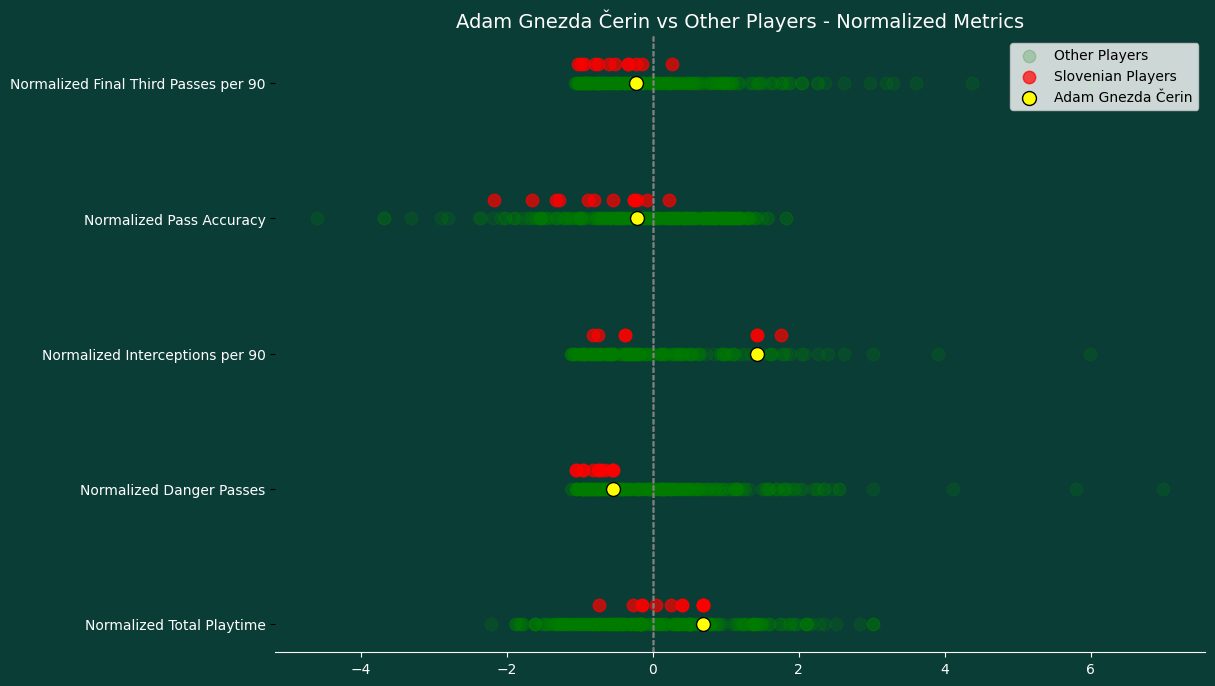

In [71]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler

# Assuming 'merged_player_stats_all_with_final_third' has the columns 'danger_passes_per_90', 'playtime_minutes', 
# 'interceptions_per_90', 'pass_accuracy', 'final_third_passes_per_90', 'player_name', and 'nationality'

# Normalize all five metrics using Z-scores
scaler = StandardScaler()
merged_player_stats_all_with_final_third['z_danger_passes'] = scaler.fit_transform(merged_player_stats_all_with_final_third[['danger_passes_per_90']])
merged_player_stats_all_with_final_third['z_playtime'] = scaler.fit_transform(merged_player_stats_all_with_final_third[['playtime_minutes']])
merged_player_stats_all_with_final_third['z_interceptions'] = scaler.fit_transform(merged_player_stats_all_with_final_third[['interceptions_per_90']])
merged_player_stats_all_with_final_third['z_pass_accuracy'] = scaler.fit_transform(merged_player_stats_all_with_final_third[['pass_accuracy']])
merged_player_stats_all_with_final_third['z_final_third_passes'] = scaler.fit_transform(merged_player_stats_all_with_final_third[['final_third_passes_per_90']])

# Define the five metrics
metrics = ['Normalized Total Playtime','Normalized Danger Passes',  'Normalized Interceptions per 90', 'Normalized Pass Accuracy', 'Normalized Final Third Passes per 90']

# Create a figure with a dark background
plt.figure(figsize=(12, 8), facecolor='#0b3d37')
ax = plt.gca()
ax.set_facecolor('#0b3d37')

# Set the y-axis offset for Slovenian players
y_offset_slovenians = 0.07  # Small offset for Slovenian players

# Y-axis positions for the five metrics
metric_positions = np.array([1, 1.5, 2, 2.5, 3])  # Five metrics with closer spacing

# Loop through each metric and plot the players' data for that metric
for i, metric in enumerate(metrics):
    if metric == 'Normalized Total Playtime':
        column = 'z_playtime'
    elif metric == 'Normalized Danger Passes':
        column = 'z_danger_passes'
    elif metric == 'Normalized Interceptions per 90':
        column = 'z_interceptions'
    elif metric == 'Normalized Pass Accuracy':
        column = 'z_pass_accuracy'
    elif metric == 'Normalized Final Third Passes per 90':
        column = 'z_final_third_passes'
    
    # Plot other players as dots in green
    other_players = merged_player_stats_all_with_final_third[merged_player_stats_all_with_final_third['nationality'] != "Slovenia"]
    plt.scatter(other_players[column], [metric_positions[i]]*len(other_players), color='green', alpha=0.2, s=80, label="Other Players" if i == 0 else "")

    # Plot Slovenian players with a slight y-axis offset in red
    slovenian_players = merged_player_stats_all_with_final_third[merged_player_stats_all_with_final_third['nationality'] == "Slovenia"]
    plt.scatter(slovenian_players[column], [metric_positions[i] + y_offset_slovenians]*len(slovenian_players), color='red', alpha=0.7, s=80, label="Slovenian Players" if i == 0 else "")

    # Highlight Adam Gnezda Čerin with a square in yellow (shown in both categories)
    cerin_data = merged_player_stats_all_with_final_third[merged_player_stats_all_with_final_third['player_name'] == "Adam Gnezda Čerin"]
    plt.scatter(cerin_data[column], [metric_positions[i]], color='yellow', edgecolor='black', label="Adam Gnezda Čerin", s=100)

    # Plot the average line for this metric (normalized mean is 0)
    plt.axvline(x=0, color='grey', linestyle='--', label=f'{metric} Avg: 0' if i == 0 else "", linewidth=1)

# Remove y-axis labels and ticks as they're not relevant for this plot
plt.yticks(metric_positions, metrics, color='white')

# Add title and style the plot
plt.title('Adam Gnezda Čerin vs Other Players - Normalized Metrics', color='white', fontsize=14)

# Customize the plot's aesthetics for a dark mode appearance
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('white')
ax.tick_params(axis='x', colors='white')

# Add a legend (ensuring it's not duplicated)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[:3], labels[:3], loc='upper right')

# Show the plot
plt.show()
